In [65]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_curve, auc,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sn
import plotly.io as pio
pio.renderers.default = "notebook_connected"  # Embeds full JS for HTML export

In [66]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [67]:
# Analyze the original dataset
df_CellDNA=pd.read_csv("ML_HW_Data_CellDNA.csv",header=None)
print("Shape : ", df_CellDNA.shape)
print('********************************************')
print("checking for null columns :\n ", df_CellDNA.isnull().sum())
print('********************************************')
print("describe: \n ",df_CellDNA.describe())
print('********************************************')

Shape :  (1217, 14)
********************************************
checking for null columns :
  0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64
********************************************
describe: 
                  0            1            2            3            4   \
count  1217.000000  1217.000000  1217.000000  1217.000000  1217.000000   
mean    200.366475   419.476953   211.335155    33.388599     9.376939   
std     135.665649   215.563920   141.592818    19.152143     3.634969   
min      70.000000    28.176471    27.870130    10.282437     3.080963   
25%     107.000000   243.400000    96.200000    18.760441     7.529888   
50%     160.000000   415.360000   183.834286    27.832476     8.463304   
75%     252.000000   611.128440   292.824742    44.462419     9.801152   
max    1089.000000   773.919643   575.340206   155.330123    43.487111   

                5            6            7            

There is no missing data in the original dataset. 
We can proceed with the analysis without needing to handle missing values. 
Keeping only the relevant columns for further analysis.

In [68]:
X_df = df_CellDNA.drop(columns=[13])  # Features DataFrame
X = zscore(X_df, axis=0).values  #  standardized value (zscore per column ) 
y=np.where(df_CellDNA[13].values==0,0,1)  # Target variable (last column)

In [69]:
X_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,222,31.189189,40.342342,35.579087,8.883917,0.968325,-80.113673,222,1,16.812471,0.816176,0.578125,78.591
1,73,29.493151,271.397260,15.517202,6.407490,0.910764,76.042946,73,1,9.640876,0.858824,0.608333,39.217
2,256,58.816406,289.941406,37.226013,9.863895,0.964256,85.324742,256,1,18.054067,0.752941,0.562637,89.111
3,126,71.023810,477.412698,13.112980,12.790672,0.220351,63.523477,126,1,12.666025,0.881119,0.646154,43.832
4,225,90.808889,541.946667,44.463110,7.858879,0.984256,-52.874983,225,1,16.925688,0.728155,0.252525,90.072


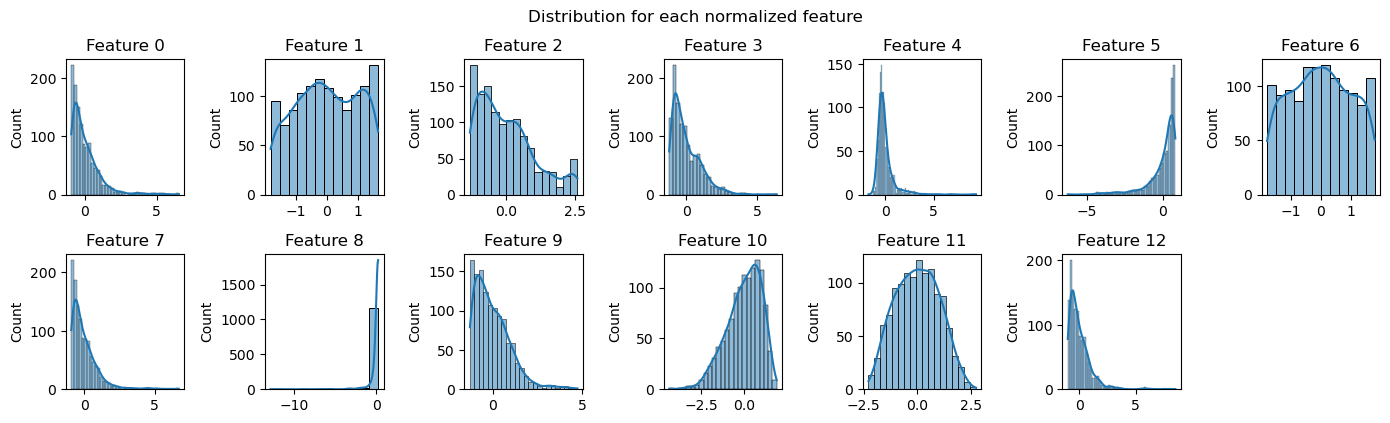

In [70]:
plot_num = plt.figure(figsize=(14, 8))
plt.suptitle('Distribution for each normalized feature')

plotnum = 1
for i in range(X.shape[1]):
    plt.subplot(4, 7, plotnum)
    sn.histplot(X[:, i], kde=True)
    plt.title(f'Feature {i}')
    plotnum += 1

plt.tight_layout()
plt.show()

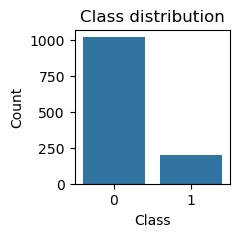

In [71]:
plt.figure(figsize=(2, 2))
sn.countplot(x=y)
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Target Variable seesm to be highly imbalanced, Somthing to consider while looking at results

In [72]:
# Create SVM with RBF kernel
model = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
model.fit(X, y)

y_pred = model.predict(X)

# Metrics
print("Accuracy:", accuracy_score(y, y_pred))
print(classification_report(y, y_pred))

Accuracy: 0.9276910435497124
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1017
           1       0.83      0.71      0.76       200

    accuracy                           0.93      1217
   macro avg       0.89      0.84      0.86      1217
weighted avg       0.92      0.93      0.93      1217



In [73]:
from sklearn.metrics import precision_recall_fscore_support

C_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]

results = []

for C in C_values:
    for gamma in gamma_values:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X, y)
        y_pred = model.predict(X)

        acc = accuracy_score(y, y_pred,)
        precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred,zero_division=0)

        results.append({
            'C': C,
            'gamma': gamma,
            'accuracy': acc,
            'precision_class0': precision[0],
            'precision_class1': precision[1],
            'recall_class0': recall[0],
            'recall_class1': recall[1],
            'f1_class0': f1[0],
            'f1_class1': f1[1]
        })

results_df = pd.DataFrame(results)
print(results_df)

      C  gamma  accuracy  precision_class0  precision_class1  recall_class0  \
0   0.1   0.01  0.835661          0.835661          0.000000       1.000000   
1   0.1   0.10  0.903040          0.910502          0.836066       0.980334   
2   0.1   1.00  0.835661          0.835661          0.000000       1.000000   
3   1.0   0.01  0.909614          0.924228          0.804054       0.971485   
4   1.0   0.10  0.931800          0.947318          0.838150       0.972468   
5   1.0   1.00  0.973706          0.973103          0.977273       0.996067   
6  10.0   0.01  0.923583          0.941683          0.812865       0.968535   
7  10.0   0.10  0.952342          0.965082          0.881720       0.978368   
8  10.0   1.00  1.000000          1.000000          1.000000       1.000000   

   recall_class1  f1_class0  f1_class1  
0          0.000   0.910474   0.000000  
1          0.510   0.944129   0.633540  
2          0.000   0.910474   0.000000  
3          0.595   0.947267   0.683908  
4   

For imbalanced datasets, accuracy alone can be misleading because it may reflect the dominance of the majority class. Therefore, Recall and F1-score are more informative metrics, particularly for evaluating the performance on the minority class. In this analysis, these metrics were also considered to provide a more comprehensive evaluation of the model.

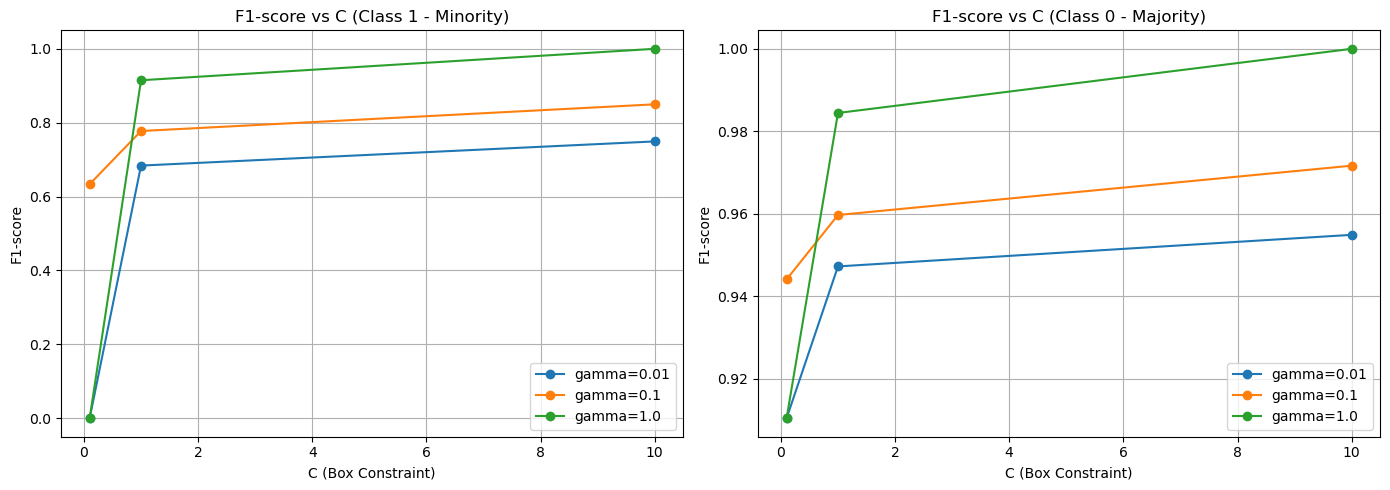

In [74]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --------- Class 1 (Minority) ---------
for gamma in [0.01, 0.1, 1.0]:
    subset = results_df[results_df['gamma'] == gamma]
    axes[0].plot(subset['C'], subset['f1_class1'], marker='o', label=f'gamma={gamma}')

axes[0].set_title("F1-score vs C (Class 1 - Minority)")
axes[0].set_xlabel("C (Box Constraint)")
axes[0].set_ylabel("F1-score")
axes[0].grid(True)
axes[0].legend()


# --------- Class 0 (Majority) ---------
for gamma in [0.01, 0.1, 1.0]:
    subset = results_df[results_df['gamma'] == gamma]
    axes[1].plot(subset['C'], subset['f1_class0'], marker='o', label=f'gamma={gamma}')

axes[1].set_title("F1-score vs C (Class 0 - Majority)")
axes[1].set_xlabel("C (Box Constraint)")
axes[1].set_ylabel("F1-score")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

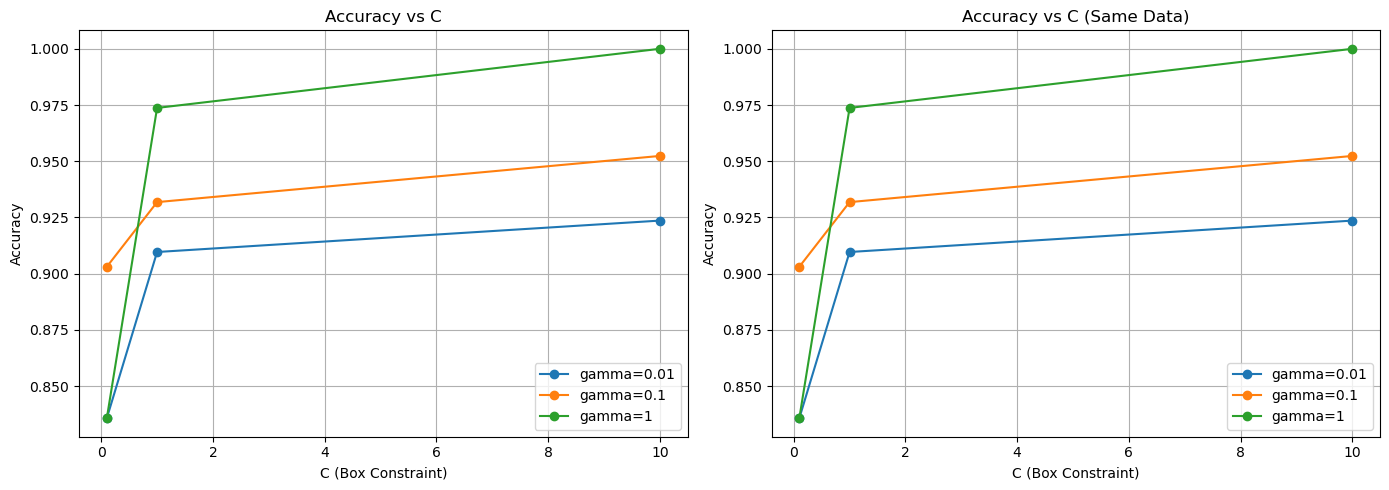

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --------- Accuracy (Plot 1) ---------
for gamma in gamma_values:
    subset = results_df[results_df['gamma'] == gamma]
    axes[0].plot(subset['C'], subset['accuracy'], marker='o', label=f'gamma={gamma}')

axes[0].set_title("Accuracy vs C")
axes[0].set_xlabel("C (Box Constraint)")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()


# --------- Accuracy (Plot 2 - duplicate for consistency) ---------
for gamma in gamma_values:
    subset = results_df[results_df['gamma'] == gamma]
    axes[1].plot(subset['C'], subset['accuracy'], marker='o', label=f'gamma={gamma}')

axes[1].set_title("Accuracy vs C (Same Data)")
axes[1].set_xlabel("C (Box Constraint)")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

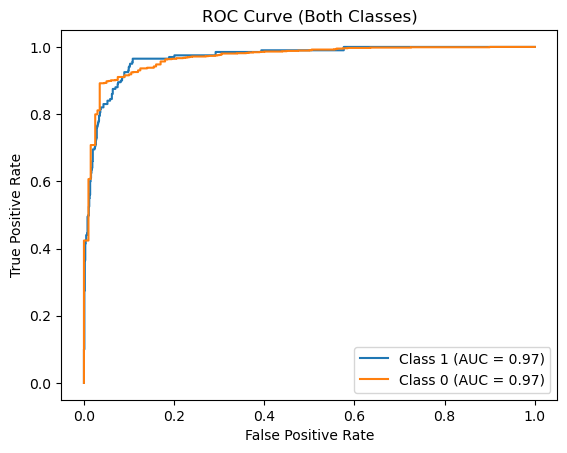

In [76]:
model = SVC(kernel='rbf', C=1, gamma=0.1, probability=True)
model.fit(X, y)

y_prob = model.predict_proba(X)

# For class 1
fpr1, tpr1, _ = roc_curve(y, y_prob[:, 1],pos_label=1)
roc_auc1 = auc(fpr1, tpr1)

# For class 0
fpr0, tpr0, _ = roc_curve(y, y_prob[:, 0],pos_label=0)
roc_auc0 = auc(fpr0, tpr0)

plt.plot(fpr1, tpr1, label=f'Class 1 (AUC = {roc_auc1:.2f})')
plt.plot(fpr0, tpr0, label=f'Class 0 (AUC = {roc_auc0:.2f})')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Both Classes)")
plt.legend()
plt.show()